In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



In [46]:
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB,BernoulliNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

In [47]:
train_data = fetch_20newsgroups(
    subset="train",
    remove=("headers", "footers", "quotes")
)

In [48]:
test_data = fetch_20newsgroups(
    subset="test",
    remove=("headers", "footers", "quotes")
)

In [49]:
X_train_text = train_data.data
y_train = train_data.target

X_test_text = test_data.data
y_test = test_data.target

class_names = train_data.target_names

In [50]:
print("Training documents :", len(X_train_text))
print("Testing documents :", len(X_test_text))
print("Number of classes :", len(class_names))



Training documents : 11314
Testing documents : 7532
Number of classes : 20


In [51]:
vectorizer = CountVectorizer(
    stop_words="english",
    min_df=2
)
X_train = vectorizer.fit_transform(X_train_text)
X_test = vectorizer.transform(X_test_text)


In [52]:
print("Training feature matrix:", X_train.shape)
print("Testing feature matrix :", X_test.shape)

Training feature matrix: (11314, 39115)
Testing feature matrix : (7532, 39115)


In [53]:
mnb = MultinomialNB()

mnb.fit(
     X_train,
     y_train
)

y_pred_mnb = mnb.predict(X_test)

In [54]:
binary_vectorizer = CountVectorizer(
    stop_words="english",
    min_df=2,
    binary=True
)
X_train_binary = binary_vectorizer.fit_transform(
    X_train_text
)
X_test_binary = binary_vectorizer.transform(
    X_test_text
)

In [55]:
bnb = BernoulliNB()

bnb.fit(
    X_train_binary,
    y_train
)
y_pred_bnb = bnb.predict(
    X_test_binary
    
)

In [56]:
mnb_accuracy = accuracy_score(y_test, y_pred_mnb)
mnb_precision = precision_score(y_test, y_pred_mnb, average='weighted')
mnb_recall = recall_score(y_test, y_pred_mnb, average='weighted')
mnb_f1 = f1_score(y_test, y_pred_mnb, average='weighted')


bnb_accuracy = accuracy_score(y_test, y_pred_bnb)
bnb_precision = precision_score(y_test, y_pred_bnb, average='weighted')
bnb_recall = recall_score(y_test, y_pred_bnb, average='weighted')
bnb_f1 = f1_score(y_test, y_pred_bnb, average='weighted')


results = pd.DataFrame({
    'Model': ['MultinomialNB', 'BernoulliNB'],
    'Accuracy': [mnb_accuracy, bnb_accuracy],
    'Precision': [mnb_precision, bnb_precision],
    'Recall': [mnb_recall, bnb_recall],
    'F1 Score': [mnb_f1, bnb_f1]
})

print(results)

           Model  Accuracy  Precision    Recall  F1 Score
0  MultinomialNB  0.651089   0.642532  0.651089  0.629644
1    BernoulliNB  0.485130   0.627034  0.485130  0.480839


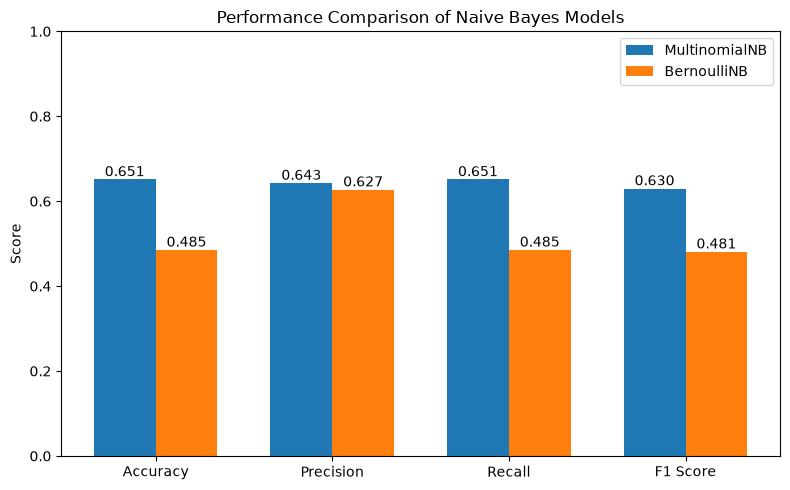

In [57]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(8,5))

ax.bar(x - width/2,
       [mnb_accuracy, mnb_precision, mnb_recall, mnb_f1],
       width,
       label='MultinomialNB')

ax.bar(x + width/2,
       [bnb_accuracy, bnb_precision, bnb_recall, bnb_f1],
       width,
       label='BernoulliNB')

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("Performance Comparison of Naive Bayes Models")
ax.legend()

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f')

plt.tight_layout()
plt.show()